<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Digital Image Processing
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Ideal High Pass Filter
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

# Ideal High Pass Filter
## An Ideal High Pass Filter is a frequency domain filter that removes low-frequency components and preserves high-frequency components of an image.
## It is called ideal because it uses a perfect (sharp) cutoff.
# Mathematical Expression 
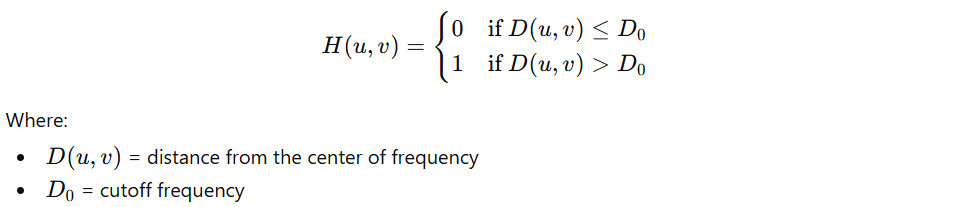
# Working Principle 
## - The center of the frequency spectrum contains low frequencies (smooth intensity variations).
## - The outer regions contain high frequencies (edges, fine details).
## IHPF:
## - Removes the center region
## - Keeps the outer region

# Effect on Image
## After applying IHPF:
### Smooth areas → suppressed
### Edges and details → enhanced
### Output looks like an edge-highlighted image

# Characteristics
### Sharp Cutoff : Sudden transition between pass and stop region
### Binary Mask : Values are only 0 or 1
### High Edge Enhancement : Strong emphasis on edges and noise

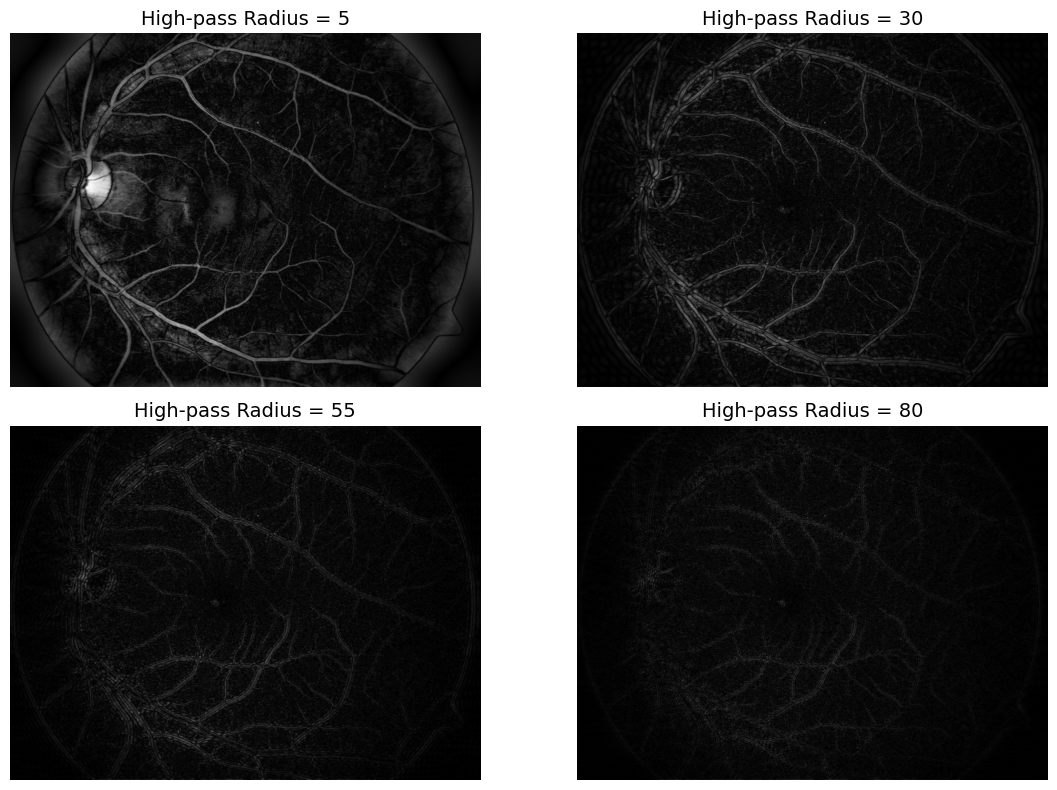

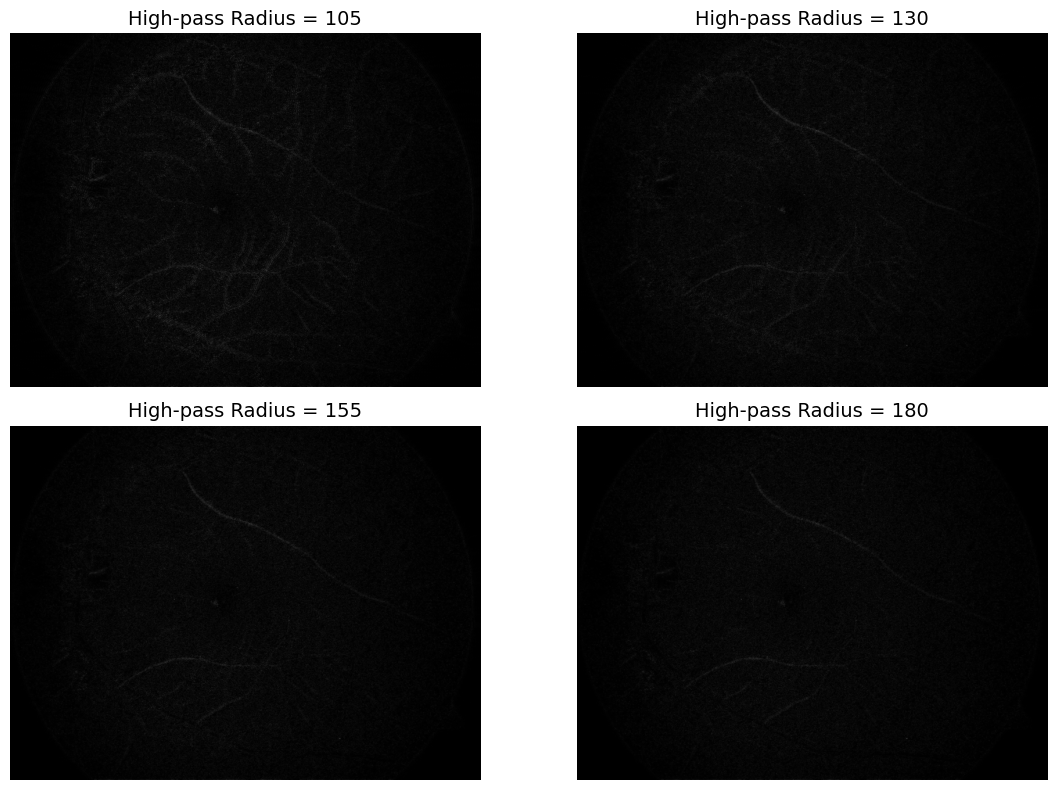

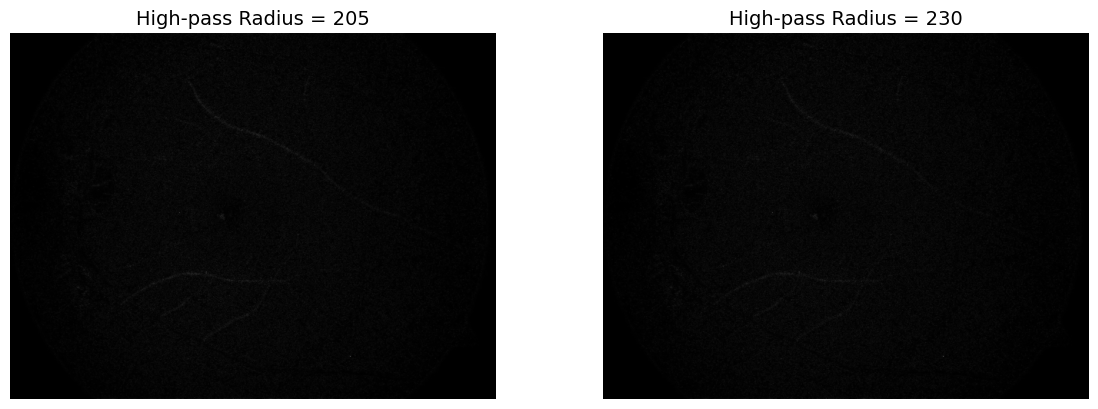

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread("image2.jpg", 0)

# Fourier Transform
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Image size
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Radii for filter
radii = list(range(5, 231, 25))

batch_size = 4

for i in range(0, len(radii), batch_size):
    plt.figure(figsize=(12, 8)) 
    
    batch = radii[i:i+batch_size]
    
    for j, D0 in enumerate(batch):
        x, y = np.ogrid[:rows, :cols]
        # High-pass mask: keep frequencies outside the circle
        mask = ((x - crow)**2 + (y - ccol)**2 >= D0**2)

        filtered = dft_shift * mask
        img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
        img_back = np.abs(img_back)

        plt.subplot(2, 2, j+1)
        plt.imshow(img_back, cmap='gray')
        plt.title(f'High-pass Radius = {D0}', fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()